# 🩸 Diabetes Dataset — Exploratory Data Analysis (EDA)
**Member 1's notebook**

Goal: Understand the data before building any models.

Run cells one by one and observe the output.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/raw/diabetes.csv')
print('Shape:', df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# Basic info
df.info()
print('\nMissing values:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                     

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


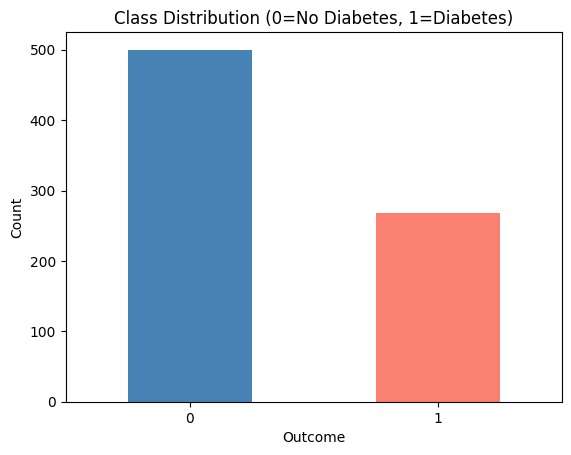

In [3]:
# Class distribution — how many diabetic vs not?
print('Class distribution:')
print(df['Outcome'].value_counts())

df['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution (0=No Diabetes, 1=Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
# Q: Is the dataset balanced? If not, how will you handle it?

In [4]:
# Statistical summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# Check for impossible 0 values
# (Glucose, BMI etc. cannot be 0 biologically)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    zeros = (df[col] == 0).sum()
    print(f'{col}: {zeros} zero values ({zeros/len(df)*100:.1f}%)')

Glucose: 5 zero values (0.7%)
BloodPressure: 35 zero values (4.6%)
SkinThickness: 227 zero values (29.6%)
Insulin: 374 zero values (48.7%)
BMI: 11 zero values (1.4%)


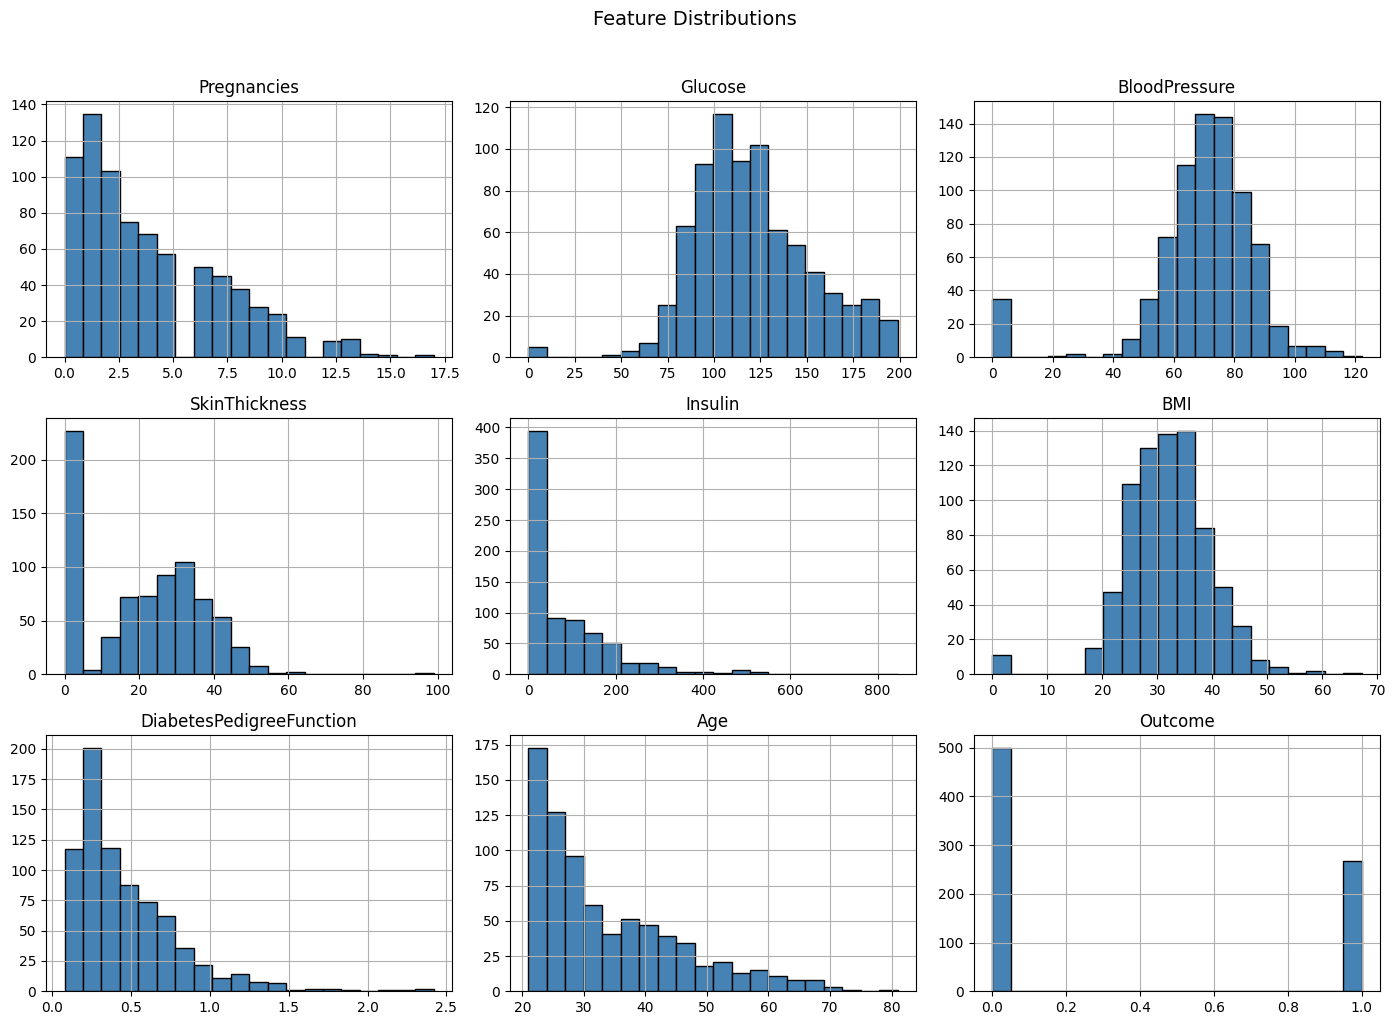

In [6]:
# Distribution of each feature
df.hist(bins=20, figsize=(14, 10), color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

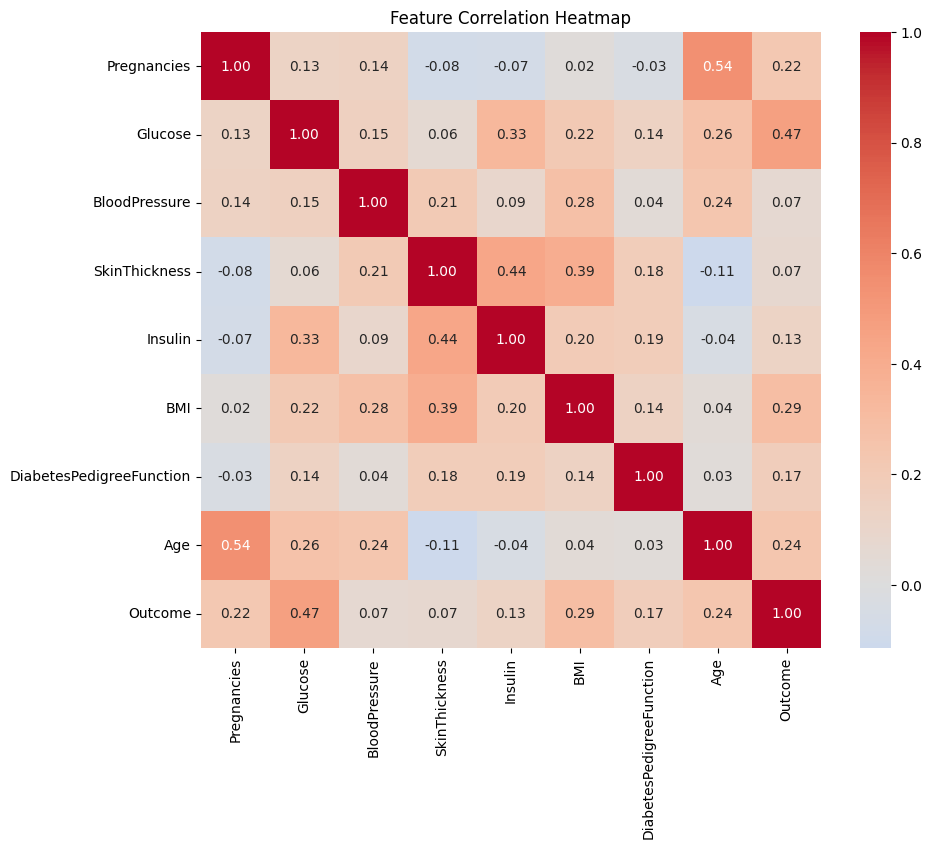

In [7]:
# Correlation heatmap — which features are correlated with each other?
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()
# Q: Which features are most correlated with Outcome (last row)?

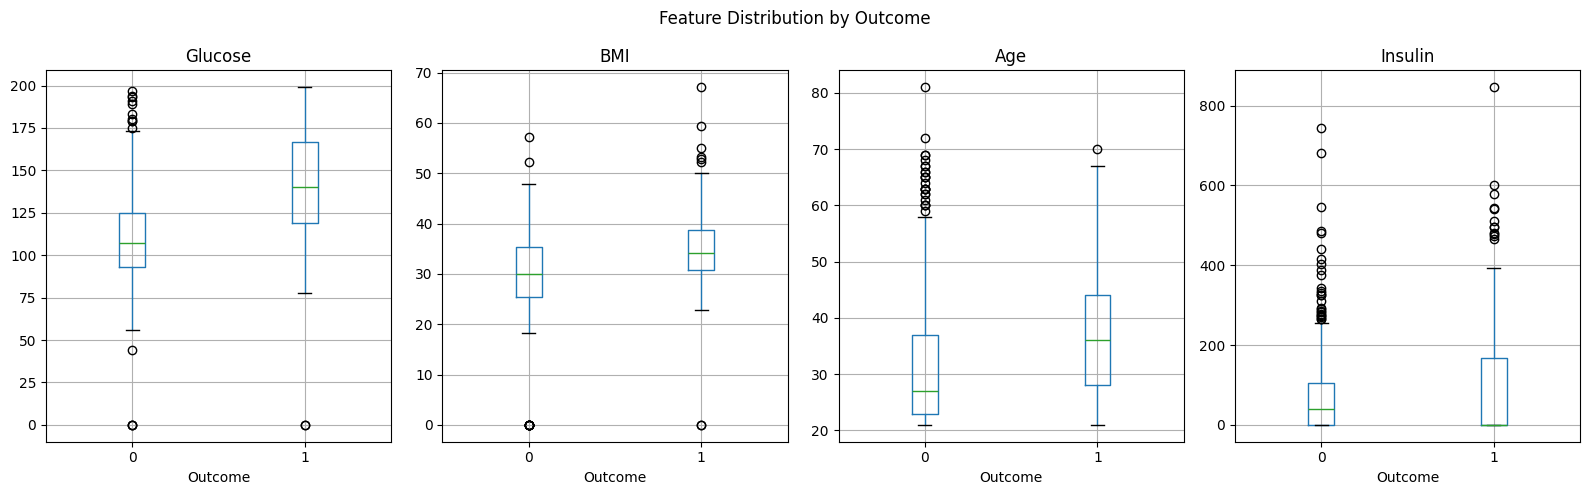

In [8]:
# Box plots — compare feature distribution for diabetic vs non-diabetic
features = ['Glucose', 'BMI', 'Age', 'Insulin']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, feat in enumerate(features):
    df.boxplot(column=feat, by='Outcome', ax=axes[i])
    axes[i].set_title(feat)
plt.suptitle('Feature Distribution by Outcome')
plt.tight_layout()
plt.show()
# Q: Which features show the clearest separation between diabetic and non-diabetic?

## Your Observations
Write your findings here after running the cells above:

- Is the dataset balanced?
- Which features have missing/zero values?
- Which features seem most predictive?
- Any surprising patterns?